### Force between two conductors using Maxwell stress tensor. 
#### This uses same setup than "notebooks/A_field_wire.ipynb",  but now multiple conductors experience forces.

Lorentz force acts F=ILB  for each conductor,  where B is the constant B field from the other wire.

This eq adds the B-field produced from another wire for two windings: $\frac{F}{L} = \frac{\mu_0I_1I_2}{2 \pi r}$

where L is the length of wires and r is their disntace

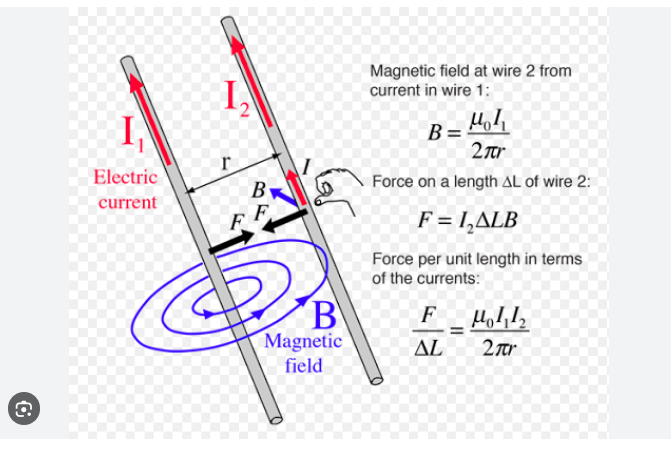

Our fem models is easy to verify with this example, since it is simple



Lets solve:
I1 = 100A
I2 = -50A
L  =  5m
mu = mu0
r = 0.6 m   // wires are 0.05 radius, so their midpoints are 0.6+0.05+0.05 = 0.7m apart

this gives,  F/L = 0.001666617512 N/m        
force is repelling, since current flows different direcitons. 

Lets make geometry for this using gmsh. We use "meshes/wire.ipynb" as a base.

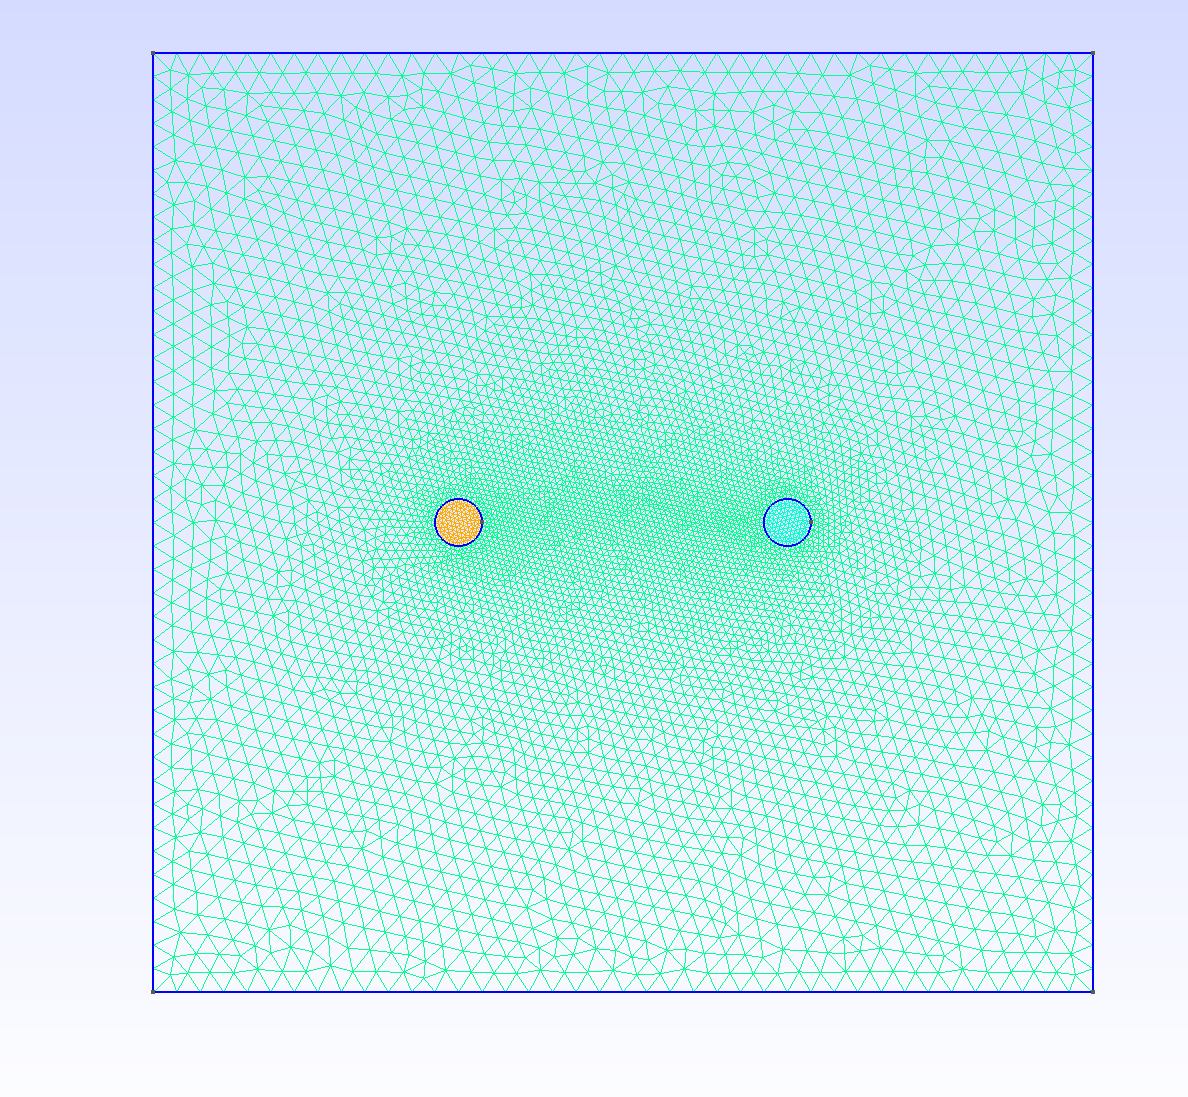


Let's solve A field  ->  B-field -> Force using maxwell stress tensor


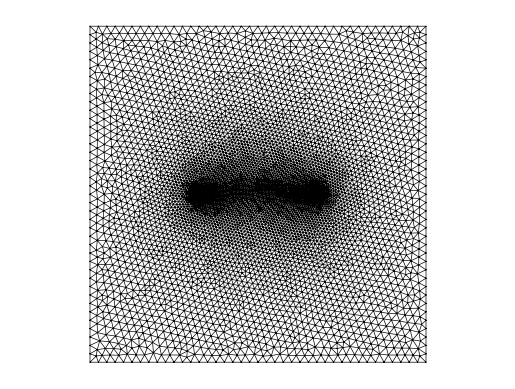

In [2]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/two_wires.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

We are solving Amperes law, and material law

\begin{equation} \nabla \times \mathbf{H} = \mathbf{J} \end{equation}

\begin{equation} \mathbf{B} = \mu \mathbf{H} \end{equation}

Our problems setup is:

<!-- \begin{equation} -\nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = J_z. \end{equation} \quad  \in \Omega -->

\begin{equation*} - \nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = J_z  \quad  \in \Omega_{conductors}  \end{equation*} 

\begin{equation*} - \nabla \cdot \left( \frac{1}{\mu} \nabla A_z \right) = 0  \quad  \in \Omega_{air}  \end{equation*}

\begin{equation*}  A_z = 0 \quad \in \partial \Omega  \end{equation*}


Linear basis functions for each domain. Az is easy to solve with these

In [4]:
e = ElementTriP1()
basis = Basis(mesh, e)
basis_wire_1 = basis.with_elements(mesh.subdomains["wire1"])
basis_wire_2 = basis.with_elements(mesh.subdomains["wire2"])
basis_air = basis.with_elements(mesh.subdomains["air"])


print(basis_wire_1)
print(basis_wire_2)
print(basis_air)
print(basis)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 6035
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 212
  Number of DOFs: 6035
  Size: 45792 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 11484
  Number of DOFs: 6035
  Size: 2480544 B
<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 11908
  Number of DOFs: 6035
  Size: 2572128 B


In [ ]:
# Small debug/test  that geometry works:

# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

wire_area_1 = area.assemble(basis_wire_1)
wire_area_2 = area.assemble(basis_wire_2)

# should be area = 0.007853981634

print("Win area 1: ", wire_area_1)
print("Win area 2: ", wire_area_2)

Win area 1:  0.007803612880645126
Win area 2:  0.007803612880645102


In [ ]:

# w.mu little coonfusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def rhs(v, w):
    return w.J * v


mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_wire = mu0

S_mat = laplace.assemble(basis_air, mu=mu_air)
S_mat += laplace.assemble(basis_wire_1, mu=mu_wire)
S_mat += laplace.assemble(basis_wire_2, mu=mu_wire)

# Wire 1
I_1 = 100 # Amperes
J_wire_1 = I_1/wire_area_1
print(J_wire_1)


# Wire
I_2 = -50 # Amperes
J_wire_2 = I_2/wire_area_2
print(J_wire_2)

# other regions dont have current
J_air =  0

b = rhs.assemble(basis_wire_1, J = J_wire_1)
b +=  rhs.assemble(basis_wire_2, J = J_wire_2)
b +=  rhs.assemble(basis_air, J = J_air)
